# Demo 6 — Ask the image a question

_Section 6: Image Understanding._

Understanding asks: **"What is going on in this scene?"** — not just *what* and *where*, but relationships and meaning. We'll run the photo through a **vision-language model** and ask it questions, then see how well it understands what's happening.

In [1]:
import warnings

import cv2
import matplotlib.pyplot as plt
from PIL import Image
from transformers import pipeline
from transformers.utils import logging

warnings.filterwarnings("ignore")
logging.set_verbosity_error()

IMG_PATH = "demo.jpg"  # the shared image used across all demos

/Users/mahyoubm/Documents/adhoc/cv-intro/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
objc[71175]: Class AVFFrameReceiver is implemented in both /Users/mahyoubm/Documents/adhoc/cv-intro/.venv/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x113a5c3a8) and /Users/mahyoubm/Documents/adhoc/cv-intro/.venv/lib/python3.12/site-packages/av/.dylibs/libavdevice.62.3.102.dylib (0x1292143a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[71175]: Class AVFAudioReceiver is implemented in both /Users/mahyoubm/Documents/adhoc/cv-intro/.venv/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x113a5c3f8) and /Users/mahyoubm/Documents/adhoc/cv-intro/.venv/lib/python3.12/site-packages/av/.dylibs/liba

## 1. Load the image and a vision-language model

**SmolVLM2-500M** is a small, fast VLM designed to run on-device (even a phone). It connects **vision to language**: give it an image plus a text question, get a text answer back.

Loading weights: 100%|██████████| 489/489 [00:00<00:00, 17357.65it/s]


Loaded SmolVLM2-500M — a mobile-friendly vision-language model.


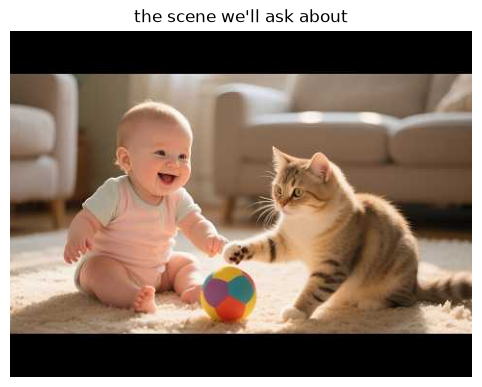

In [2]:
bgr = cv2.imread(IMG_PATH)                    # OpenCV loads as BGR
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)    # -> RGB
image = Image.fromarray(rgb)                  # the VLM takes a PIL image

vlm = pipeline("image-text-to-text", model="HuggingFaceTB/SmolVLM2-500M-Video-Instruct")
print("Loaded SmolVLM2-500M — a mobile-friendly vision-language model.")

plt.figure(figsize=(6, 4.5))
plt.imshow(image)
plt.axis("off")
plt.title("the scene we'll ask about")
plt.show()

In [3]:
def ask(question, max_new_tokens=100):
    """Ask the vision-language model a question about the image."""
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": question},
        ],
    }]
    out = vlm(text=messages, max_new_tokens=max_new_tokens)
    answer = out[0]["generated_text"][-1]["content"].strip()
    print(f"Q: {question}\nA: {answer}\n")
    return answer

## 2. From pixels to a sentence (captioning)

First, just ask it to describe the scene. Notice it doesn't list labels — it writes a **sentence about what's happening**.

In [4]:
_ = ask("Describe this image in one sentence.")

Q: Describe this image in one sentence.
A: A baby and a cat are playing with a colorful ball on a carpeted floor, with the cat looking at the ball.



## 3. Ask questions about the scene (VQA)

This is **Visual Question Answering**: the model reads the pixels *and* the question together to answer.

In [5]:
_ = ask("How many living things are in the image, and what are they?")
_ = ask("What color is the ball?")
_ = ask("What is the baby doing?")

Q: How many living things are in the image, and what are they?
A: There are two living things in the image: a baby and a cat.

Q: What color is the ball?
A: The ball is multicolored.

Q: What is the baby doing?
A: The baby is playing with a colorful ball.



## 4. Beyond "what" and "where": relationships

The real leap is understanding how things **relate** — not just "baby" + "cat" + "ball", but that they're interacting.

In [6]:
_ = ask("What is the relationship between the baby and the cat?")
_ = ask("Where is this scene taking place?")

Q: What is the relationship between the baby and the cat?
A: The baby and the cat appear to be playing together, which suggests a close bond between them.

Q: Where is this scene taking place?
A: The scene takes place in a living room.



## 5. Understanding is still the frontier

Questions about **intent, context, or what happens next** need common sense — this is where even good models get shaky. Try a few and see.

In [7]:
_ = ask("What do you think will happen next?")
_ = ask("Is the baby in any danger? Explain your reasoning.")

Q: What do you think will happen next?
A: The cat will likely play with the ball, chasing it around the room, and eventually playfully batting at it.

Q: Is the baby in any danger? Explain your reasoning.
A: The baby is not in any danger. The baby is playing with a ball, which is a common activity for babies. The presence of the cat in the background does not indicate any potential danger to the baby.



## Takeaway

We've gone all the way from **pixels → numbers → labels → boxes → masks → a conversation about the scene**.

Computers are getting remarkably good at **seeing**. Truly **understanding** a scene the way we do — intent, context, common sense — is the hard, open frontier.